Первые 5 строк датасета:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Статистика по числовым признакам:
       

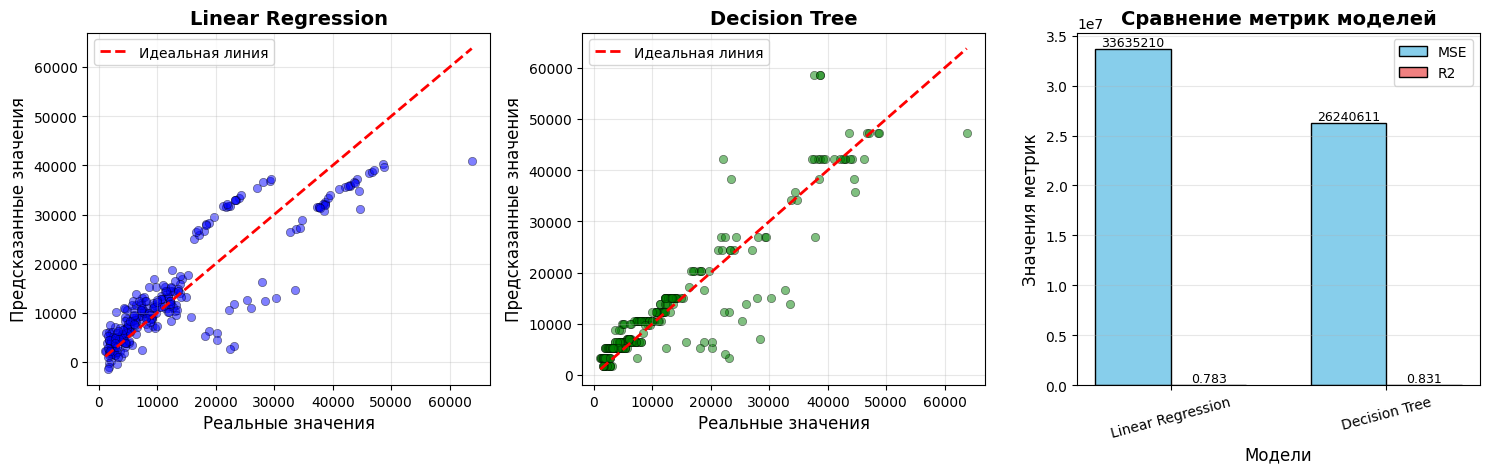


ВАЖНОСТЬ ПРИЗНАКОВ (ДЕРЕВО РЕШЕНИЙ)
    feature  importance
4    smoker    0.692341
2       bmi    0.179530
0       age    0.117584
3  children    0.007437
5    region    0.002203
1       sex    0.000904


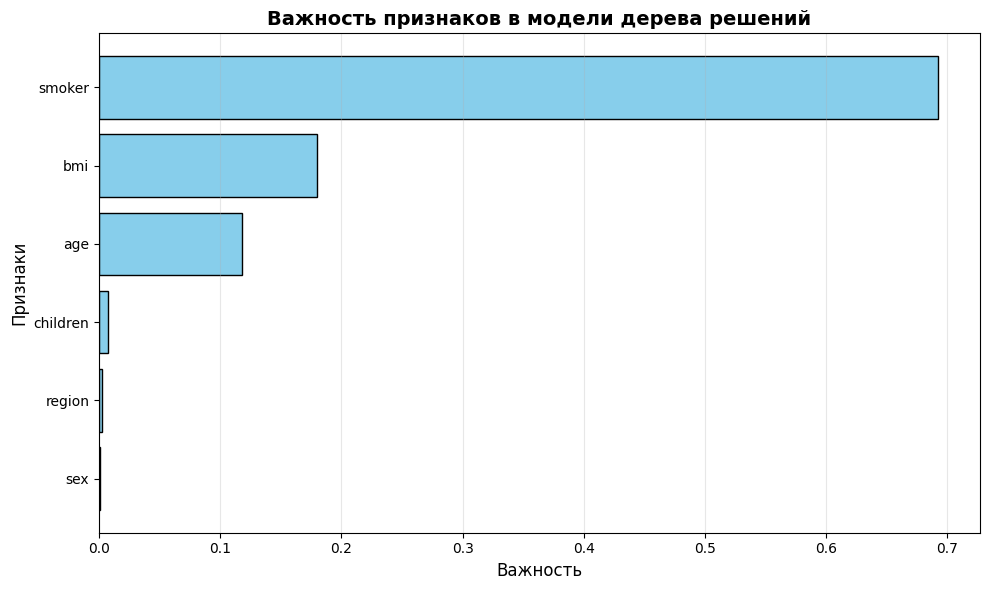


ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВОГО КЛИЕНТА

Данные нового клиента:
Возраст: 35 лет
Пол: мужской
BMI: 28.5
Количество детей: 2
Курильщик: да
Регион: southeast

Предсказанная стоимость страховки:
Линейная регрессия: $30,556.78
Дерево решений: $20,323.20
Среднее значение: $25,439.99


In [2]:
# Лабораторная работа №3
# Вариант 4: Прогноз стоимости медицинского страхования

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import requests
import io

# 1. Загрузка данных из интернета
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

print("Первые 5 строк датасета:")
print(df.head())
print("\nИнформация о датасете:")
print(df.info())
print("\nСтатистика по числовым признакам:")
print(df.describe())

# 2. Подготовка признаков
X = df.drop('charges', axis=1)
y = df['charges']

# Кодирование категориальных признаков
le = LabelEncoder()
X['sex'] = le.fit_transform(X['sex'])
X['smoker'] = le.fit_transform(X['smoker'])
X['region'] = le.fit_transform(X['region'])

print("\nПризнаки после кодирования:")
print(X.head())

# 3. Разделение на train/test (80% обучающая, 20% тестовая)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# 4. Обучение моделей
print("\n" + "="*50)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*50)

# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
print("\nМодель линейной регрессии обучена")

# Дерево решений
dt = DecisionTreeRegressor(random_state=42, max_depth=5)  # ограничим глубину для предотвращения переобучения
dt.fit(X_train, y_train)
print("Модель дерева решений обучена")

# 5. Предсказание
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

# 6. Оценка моделей
print("\n" + "="*50)
print("ОЦЕНКА МОДЕЛЕЙ")
print("="*50)

print("\nLinear Regression:")
print(f"MSE (среднеквадратичная ошибка): {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"RMSE (корень из MSE): {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")
print(f"R2 score (коэффициент детерминации): {r2_score(y_test, y_pred_lr):.4f}")

print("\nDecision Tree:")
print(f"MSE (среднеквадратичная ошибка): {mean_squared_error(y_test, y_pred_dt):.2f}")
print(f"RMSE (корень из MSE): {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.2f}")
print(f"R2 score (коэффициент детерминации): {r2_score(y_test, y_pred_dt):.4f}")

# Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
if r2_score(y_test, y_pred_lr) > r2_score(y_test, y_pred_dt):
    print("Линейная регрессия показывает лучшие результаты")
else:
    print("Дерево решений показывает лучшие результаты")

# 7. Визуализация результатов
plt.figure(figsize=(15, 5))

# График 1: Линейная регрессия
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5, c='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения', fontsize=12)
plt.ylabel('Предсказанные значения', fontsize=12)
plt.title('Linear Regression', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Дерево решений
plt.subplot(1, 3, 2)
plt.scatter(y_test, y_pred_dt, alpha=0.5, c='green', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
plt.xlabel('Реальные значения', fontsize=12)
plt.ylabel('Предсказанные значения', fontsize=12)
plt.title('Decision Tree', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Сравнение ошибок
plt.subplot(1, 3, 3)
models = ['Linear Regression', 'Decision Tree']
mse_values = [mean_squared_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_dt)]
r2_values = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_dt)]

x = np.arange(len(models))
width = 0.35

bars1 = plt.bar(x - width/2, mse_values, width, label='MSE', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, r2_values, width, label='R2', color='lightcoral', edgecolor='black')

plt.xlabel('Модели', fontsize=12)
plt.ylabel('Значения метрик', fontsize=12)
plt.title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
plt.xticks(x, models, rotation=15)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.0f}' if bars == bars1 else f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Дополнительный анализ: важность признаков для дерева решений
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("ВАЖНОСТЬ ПРИЗНАКОВ (ДЕРЕВО РЕШЕНИЙ)")
print("="*50)
print(feature_importance)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue', edgecolor='black')
plt.xlabel('Важность', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Важность признаков в модели дерева решений', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 9. Пример предсказания для нового клиента
print("\n" + "="*50)
print("ПРИМЕР ПРЕДСКАЗАНИЯ ДЛЯ НОВОГО КЛИЕНТА")
print("="*50)

# Создаем данные нового клиента
new_client = pd.DataFrame({
    'age': [35],
    'sex': [1],  # 1 - male (после кодирования)
    'bmi': [28.5],
    'children': [2],
    'smoker': [1],  # 1 - yes (после кодирования)
    'region': [2]   # 2 - southeast (после кодирования)
})

# Получаем предсказания от обеих моделей
pred_lr = lr.predict(new_client)[0]
pred_dt = dt.predict(new_client)[0]

print("\nДанные нового клиента:")
print(f"Возраст: 35 лет")
print(f"Пол: мужской")
print(f"BMI: 28.5")
print(f"Количество детей: 2")
print(f"Курильщик: да")
print(f"Регион: southeast")

print(f"\nПредсказанная стоимость страховки:")
print(f"Линейная регрессия: ${pred_lr:,.2f}")
print(f"Дерево решений: ${pred_dt:,.2f}")
print(f"Среднее значение: ${(pred_lr + pred_dt)/2:,.2f}")
